In [2]:
# Bandit Experiment
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [3]:
# introduce the DKRL algorithm
import numpy as np
from tqdm import tqdm

def DKRL(y, KZ, KX, N, r, penalty, tol, T, wt = 0, verbose = 0):
    """
    Perform an double kernel representation learning.

    Parameters:
    y (numpy.ndarray): Target vector for optimization.
    KZ (numpy.ndarray): Kernel matrix Z.
    KX (numpy.ndarray): Kernel matrix X.
    N (int): Number of rows in U and V matrices.
    r (int): Number of columns in U and V matrices.
    penalty (float): Regularization parameter.
    tol (float): Tolerance for stopping criterion.
    T (int): Maximum number of iterations.
    wt (float): a number between 0 and 1 for adding identity to degenerate kernel matrix
    

    Returns:
    tuple: Final U and V matrices.
    """
    # Initialize U and V matrices randomly
    Ut = np.random.normal(loc=0, scale=1, size=(N, r))
    Vt = np.random.normal(loc=0, scale=1, size=(N, r))

    for iter in tqdm(range(T)):
        # Update U matrix
        VKX = np.repeat(np.dot(Vt.T, KX), repeats=N, axis=0)
        KZZ = np.tile(KZ, (1, r))
        DesignVt = VKX.T * KZZ  # n * (nr)
        Utt = np.linalg.solve(
            np.dot(DesignVt.T, DesignVt) + penalty * np.kron(np.eye(r, dtype=int), (1-wt) * KZ + wt * np.eye(N)),
            np.dot(DesignVt.T, y)
        )
        Utt = Utt.reshape((N, r), order="F")

        # Update V matrix
        UKZ = np.repeat(np.dot(Utt.T, KZ), repeats=N, axis=0)
        KXX = np.tile(KX, (1, r))
        DesignUt = UKZ.T * KXX  # n * (nr)
        Vtt = np.linalg.solve(
            np.dot(DesignUt.T, DesignUt) + penalty * np.kron(np.eye(r, dtype=int), (1-wt) * KX + wt * np.eye(N)),
            np.dot(DesignUt.T, y)
        )
        Vtt = Vtt.reshape((N, r), order="F")

        # Check stopping criterion
        norm_U = np.linalg.norm(Utt - Ut) / (np.linalg.norm(Ut) + 1e-3)
        norm_V = np.linalg.norm(Vtt - Vt) / (np.linalg.norm(Vt) + 1e-3)
        if verbose:
            print(f"Iteration {iter}: norm_U={norm_U}, norm_V={norm_V}")
        
        
        if norm_U < tol and norm_V < tol:
            break

        # Update Ut and Vt
        Ut = Utt
        Vt = Vtt

    y_pred = np.diag(KZ @ Utt @ Vtt.T @ KX)
    return Utt, Vtt, y_pred

In [4]:
def DKRL_pred(U, V, KZ_pred, KX_pred):
    y_pred = np.diag(KZ_pred.T @ U @ V.T @ KX_pred)
    return y_pred

In [5]:
# import the headlines and embeddings
num_actions = 100
df = pd.read_csv("unique_headlines.csv")  # Replace with your file path
headlines = np.array(df["headline"].tolist())
embeddings = np.loadtxt('embeddings.csv', delimiter=',')

# Randomly sample a subset of headlines and embeddings for evaluation
# Set a random seed for reproducibility
np.random.seed(2025)
ind = np.arange(len(headlines))  # Array with 1000 elements
sampled_ind = np.random.choice(ind, size=num_actions, replace=False)

# Randomly sample 100 elements from the array
headlines = headlines[sampled_ind]
Z = embeddings[sampled_ind]

# dimension of the embeddings
p = len(Z[1])
print("the dimension of the embeddings is: " + str(len(Z[1])))

the dimension of the embeddings is: 384


In [6]:
# Simulate projection matrix
# Simulate covariate level features from Gaussian distributions
np.random.seed(2025)
r = 2
# p = 1000
# Z = np.random.normal(loc=0, scale=1, size=(N, p))
# row_norms_Z = np.linalg.norm(Z, axis=1, keepdims=True)
# Z = Z / row_norms_Z
# sampled_ind = np.random.choice(range(N), size=N, replace=True)
# Z = Z[sampled_ind]

q = 1000
X = np.random.normal(loc=0, scale=1, size=(num_actions, q))
row_norms_X = np.linalg.norm(X, axis=1, keepdims=True)
X = X / row_norms_X

# generate random projection
np.random.seed(2025)
P = np.random.normal(loc=0, scale=1, size=(p, q))
L, S, Rt = np.linalg.svd(P, full_matrices=False)
Lr = L[:, :r]
Rr = Rt[:r, :].T
Zr = np.dot(Z, Lr) # n*r
Xr = np.dot(X, Rr) # n*r

# True reward matrix
true_reward = Zr @ Xr.T
best_reward = np.max(true_reward, axis=0)


In [7]:
# compute the kernels (simply with cosine similarity): 
penalty = 1e-3
tol = 1e-2
r = 2
T = 200

In [8]:
np.random.seed(2027)

#  ========= exploration stage ==========
N = 1000

sampled_ind_z = np.random.choice(range(num_actions), size=N, replace=True)
Zsub = Z[sampled_ind_z]
sampled_ind_x = np.random.choice(range(num_actions), size=N, replace=True)
Xsub = X[sampled_ind_x]
Zrsub = np.dot(Zsub, Lr) # n*r
Xrsub = np.dot(Xsub, Rr) # n*r
KZsub = np.dot(Zsub, Zsub.T)
KXsub = np.dot(Xsub, Xsub.T)

KZ_test = np.dot(Zsub, Z.T)
KX_test = np.dot(Xsub, X.T)

observed_reward_exploration = true_reward[sampled_ind_z, sampled_ind_x]
best_reward_exploration = best_reward[sampled_ind_x]


# generate the outcome
y = np.diag(Zrsub @ Xrsub.T)

U, V, y_hat = DKRL(y, KZsub, KXsub, N, r, penalty, tol, T, wt = 0.01)
y_pred = DKRL_pred(U, V, KZ_test, KX_test)
reward_pred = KZ_test.T @ U @ V.T @ KX_test
row_indices = np.argmax(reward_pred, axis=0)
best_reward_hat = true_reward[row_indices, range(num_actions)]




 16%|█▌        | 31/200 [00:04<00:22,  7.67it/s]


## visualize the features

In [9]:
Xeval = np.random.normal(loc=1, scale=1, size=(10000, int(q)))
column_means = np.mean(np.dot(Z, Lr) @ np.dot(Xeval, Rr).T, axis=1)
sorted_indices = np.argsort(column_means)[::-1]
top_indices = sorted_indices[:3]
bottom_indices = sorted_indices[-3:]

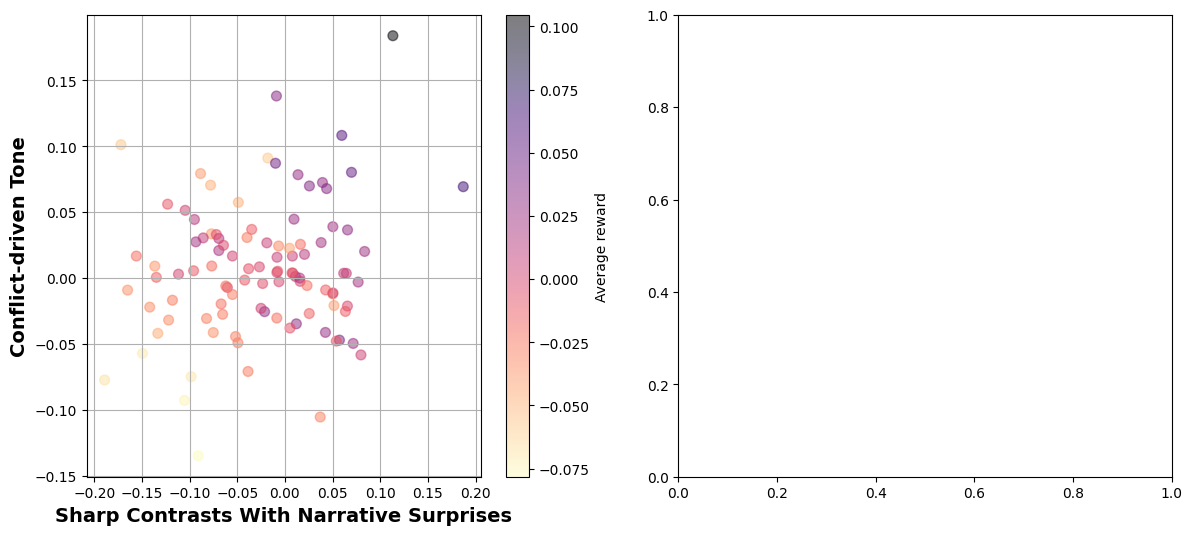

In [19]:
K_embedding = np.dot(Z[top_indices], Zsub.T)
KZ = np.dot(Z, Zsub.T)

Urep = K_embedding @ U
x1, y1 = Urep[:, 0], Urep[:, 1]

Ufull = KZ @ U
x2, y2 = Ufull[:, 0], Ufull[:, 1]
# Create figure and subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# First subplot
scatter = axes[0].scatter(x2, -y2, c=column_means, cmap='magma_r', alpha=0.5, s=50)
fig.colorbar(scatter, ax=axes[0], label='Average reward')
# axes[0].set_title(labels[0])
axes[0].set_xlabel("Sharp Contrasts With Narrative Surprises", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Conflict-driven Tone", fontsize=14, fontweight='bold')
axes[0].grid(True)

In [11]:
headlines[top_indices]

array(["Hey, I Have An Idea: Let's Deport THIS GUY, Instead",
       'Hank Green Goes Up Against A Corporate Suit To Debate An Unsexy Issue That Is Really A Big Deal',
       'This Pink Gang Attacks Sexual Predators And Rapists That Harm Them. Tell Me, What Else Can They Do?'],
      dtype='<U120')

In [46]:
headlines[bottom_indices]

array(['Here’s A List Of Uncool Problems For Ladies That We Could Fix To Make Life Easier For Everyone',
       "A Parent, A Criminal And A Jerk Walk Down The Street, But You Won't Know Who's Who Till The End",
       "Let's say I knew how to make your phone stay charged forever without plugging it into a wall again."],
      dtype='<U120')

In [16]:
### For x2
sorted_indices = np.argsort(x2)[::-1]
top_indices = sorted_indices[:10]
bottom_indices = sorted_indices[(-10):]

print(headlines[top_indices])
print(headlines[bottom_indices])

['Hank Green Goes Up Against A Corporate Suit To Debate An Unsexy Issue That Is Really A Big Deal'
 "Hey, I Have An Idea: Let's Deport THIS GUY, Instead"
 "He's black. He's a cop. He's also been stopped and frisked 30 times."
 'Floppy Ears, Soulful Eyes, Adorable Babies. And They Have Something Else People Can’t Stop Taking.'
 'By His Own Admission, Neil deGrasse Tyson Has Been Black His Whole Life. What That Taught Him.'
 "When You Realize What The Fashion World Means By 'Not My Aesthetic', It's Quite Ugly"
 "It's Not A Unique Concept, But The Way He Says It Is So Gorgeous"
 "A Neo-Nazi Got A Job At A Jewish Man's Antique Store. Can You Guess What Happened Next?"
 'As the cost of college skyrockets, one school has a radical new plan: a free education.'
 "I Love It When Lewis Black Gets Angry —It's Hilarious. And This Time, It's About Our Rights."]
["Anyone Able To Read This Won't Benefit From It, But A Lot Of You Will Want To Know About It Anyway"
 "She Won A Golden Globe And Dedicate

In [ ]:
### For y2
sorted_indices = np.argsort(-y2)[::-1]
top_indices = sorted_indices[:10]
bottom_indices = sorted_indices[(-10):]

print(headlines[top_indices])
print(headlines[bottom_indices])

["Hey, I Have An Idea: Let's Deport THIS GUY, Instead"
 "Composting 101: Why It's The Greatest, And How To Do It Yourself"
 'This Pink Gang Attacks Sexual Predators And Rapists That Harm Them. Tell Me, What Else Can They Do?'
 'Meet The Woman Who Made Google Earth Complete\n'
 'Meet The Unmanned Drones Built To Fight Poverty Instead Of People'
 'PLOT TWIST: Fox News Anchor Lays Epic Smackdown On Fox News Anchors For Obvious And Blatant Misogyny'
 "It's Not A Unique Concept, But The Way He Says It Is So Gorgeous"
 "Let's Take A Moment To Appreciate Bad-Ass Women Explorers"
 "She Knows She's Beautiful, Now A Major Agency Is Slapping Money On The Table Because They Agree"
 'John Oliver Tears Into The Awful Folks Behind 1 Of The Biggest Scams Being Run On People Today']
["A Tiny Probe Millions Of Miles Away Just Made Me The Happiest I've Been In Weeks"
 "When You Realize What The Fashion World Means By 'Not My Aesthetic', It's Quite Ugly"
 'Here’s A List Of Uncool Problems For Ladies That 

## Test out

In [105]:
# ========= exploitation stage ===========
N = 3000
r = 2

sampled_ind_xx = np.random.choice(range(num_actions), size=N, replace=True)
observed_reward_exploitation = best_reward_hat[sampled_ind_xx]
best_reward_exploitation = best_reward[sampled_ind_xx]

In [106]:
regret = np.append(best_reward_exploration - observed_reward_exploration, best_reward_exploitation - observed_reward_exploitation)
cum_regret = np.cumsum(regret)

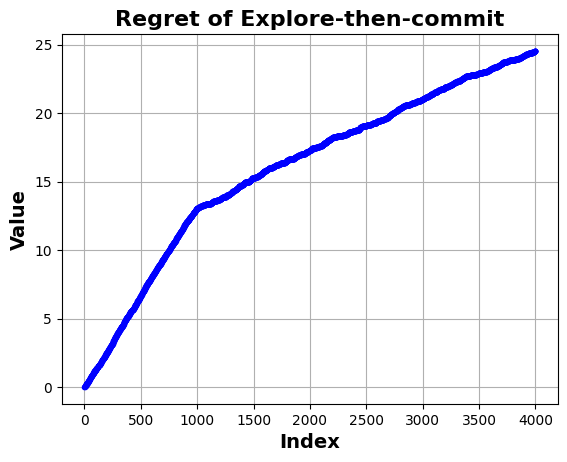

In [107]:
import numpy as np
import matplotlib.pyplot as plt

# Generate a sample 1D NumPy array

# Plot the array
plt.plot(cum_regret, marker='.', linestyle='-', color='b')

# Add labels and title
plt.xlabel("Index", fontsize=14, fontweight='bold')
plt.ylabel("Value", fontsize=14, fontweight='bold')
plt.title("Regret of Explore-then-commit", fontsize=16, fontweight='bold')

# Show grid
plt.grid(True)

# Display the plot
plt.show()


# Experiments

the dimension of the embeddings is: 384


100%|██████████| 100/100 [22:50<00:00, 13.70s/it]


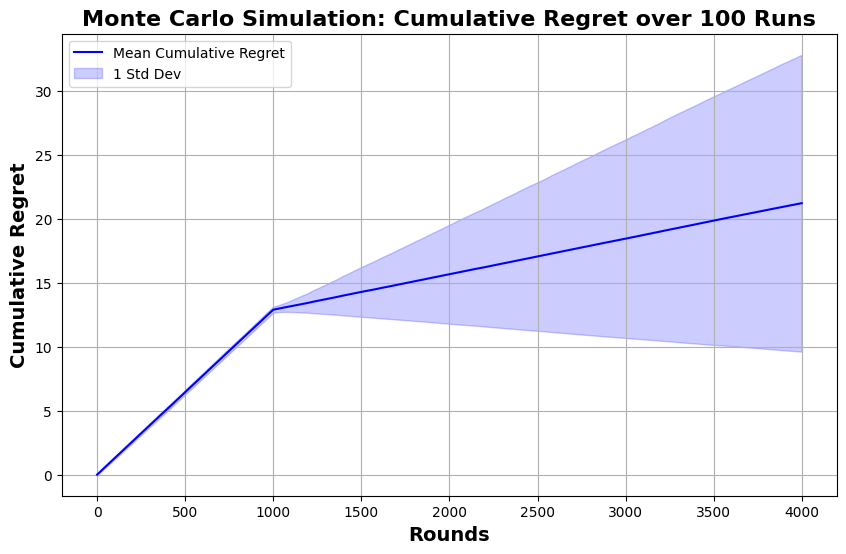

In [109]:
# import the headlines and embeddings
num_actions = 100
df = pd.read_csv("unique_headlines.csv")  # Replace with your file path
headlines = np.array(df["headline"].tolist())
embeddings = np.loadtxt('embeddings.csv', delimiter=',')

# Randomly sample a subset of headlines and embeddings for evaluation
# Set a random seed for reproducibility
np.random.seed(2025)
ind = np.arange(len(headlines))  # Array with 1000 elements
sampled_ind = np.random.choice(ind, size=num_actions, replace=False)

# Randomly sample 100 elements from the array
headlines = headlines[sampled_ind]
Z = embeddings[sampled_ind]

# dimension of the embeddings
p = len(Z[1])
print("the dimension of the embeddings is: " + str(len(Z[1])))

# ============================================================================ #

# Simulate projection matrix
# Simulate covariate level features from Gaussian distributions
np.random.seed(2025)
r = 2
# p = 1000
# Z = np.random.normal(loc=0, scale=1, size=(N, p))
# row_norms_Z = np.linalg.norm(Z, axis=1, keepdims=True)
# Z = Z / row_norms_Z
# sampled_ind = np.random.choice(range(N), size=N, replace=True)
# Z = Z[sampled_ind]

q = 1000
X = np.random.normal(loc=0, scale=1, size=(num_actions, q))
row_norms_X = np.linalg.norm(X, axis=1, keepdims=True)
X = X / row_norms_X

# generate random projection
np.random.seed(2025)
P = np.random.normal(loc=0, scale=1, size=(p, q))
L, S, Rt = np.linalg.svd(P, full_matrices=False)
Lr = L[:, :r]
Rr = Rt[:r, :].T
Zr = np.dot(Z, Lr) # n*r
Xr = np.dot(X, Rr) # n*r

# True reward matrix
true_reward = Zr @ Xr.T
best_reward = np.max(true_reward, axis=0)

# ============================================================================ #

# Set the random seed for reproducibility
np.random.seed(2025)

# Define the number of simulations
num_simulations = 100
num_exploration = 1000
num_exploitation = 3000
num_actions = 100  # Assuming actions correspond to columns

# Store cumulative regrets
all_cum_regrets = np.zeros((num_simulations, num_exploration + num_exploitation))

for sim in tqdm(range(num_simulations)):
    # ========= Exploration Stage ==========
    sampled_ind_z = np.random.choice(range(num_actions), size=num_exploration, replace=True)
    Zsub = Z[sampled_ind_z]
    sampled_ind_x = np.random.choice(range(num_actions), size=num_exploration, replace=True)
    Xsub = X[sampled_ind_x]

    Zrsub = np.dot(Zsub, Lr)  # n*r
    Xrsub = np.dot(Xsub, Rr)  # n*r
    KZsub = np.dot(Zsub, Zsub.T)
    KXsub = np.dot(Xsub, Xsub.T)

    KZ_test = np.dot(Zsub, Z.T)
    KX_test = np.dot(Xsub, X.T)

    observed_reward_exploration = true_reward[sampled_ind_z, sampled_ind_x]
    best_reward_exploration = best_reward[sampled_ind_x]

    # Generate the outcome using DKRL
    y = np.diag(Zrsub @ Xrsub.T)
    U, V, y_hat = DKRL(y, KZsub, KXsub, num_exploration, r, penalty, tol, T, wt=0.01)
    y_pred = DKRL_pred(U, V, KZ_test, KX_test)
    reward_pred = KZ_test.T @ U @ V.T @ KX_test

    row_indices = np.argmax(reward_pred, axis=0)
    best_reward_hat = true_reward[row_indices, range(num_actions)]

    # ========= Exploitation Stage ==========
    sampled_ind_xx = np.random.choice(range(num_actions), size=num_exploitation, replace=True)
    observed_reward_exploitation = best_reward_hat[sampled_ind_xx]
    best_reward_exploitation = best_reward[sampled_ind_xx]

    # Compute regret
    regret = np.append(
        best_reward_exploration - observed_reward_exploration,
        best_reward_exploitation - observed_reward_exploitation
    )

    # Compute cumulative regret
    cum_regret = np.cumsum(regret)
    
    # Store results
    all_cum_regrets[sim, :] = cum_regret



np.save("MC_simulation_results_regret.npy", all_cum_regrets)


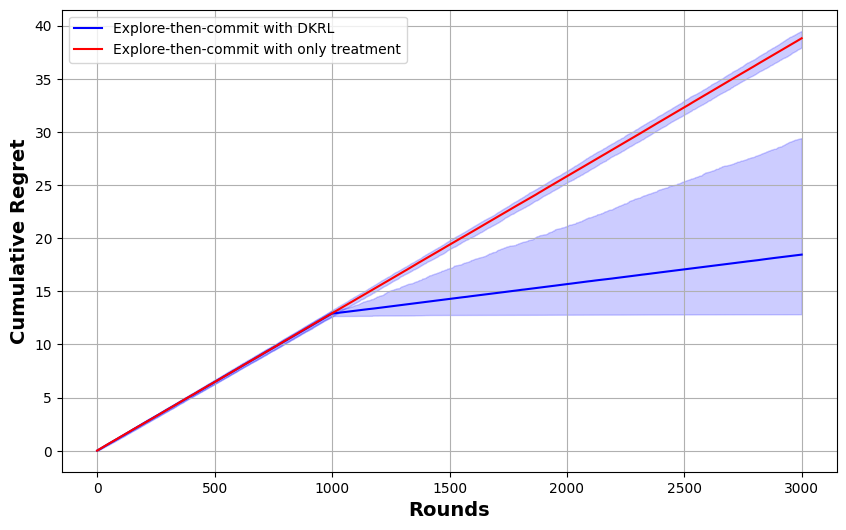

In [136]:
# 
all_cum_regrets = np.load("MC_simulation_results_regret.npy", allow_pickle=True) #.item()
all_cum_regrets = all_cum_regrets[:, range(3000)]

# Compute mean and standard deviation across simulations
mean_cum_regret = np.mean(all_cum_regrets, axis=0)
quantile_15 = np.percentile(all_cum_regrets, 15, axis=0)  # 10th percentile
quantile_85 = np.percentile(all_cum_regrets, 85, axis=0)

# 
# Generate x-axis values (rounds)
x_values = np.arange(len(mean_cum_regret[:1000]))

# Fit a regression line to mean_cum_regret
slope, intercept, _, _, _ = linregress(x_values, mean_cum_regret[:1000])

# Compute the regression line values
regression_line = slope * np.arange(len(mean_cum_regret)) + intercept

plt.figure(figsize=(10, 6))
plt.plot(mean_cum_regret, label="Explore-then-commit with DKRL", color="blue")
plt.fill_between(
    range(len(mean_cum_regret)),
    quantile_15,
    quantile_85,
    color="blue",
    alpha=0.2
)
# plt.plot(regression_line, linestyle="--", color="red", label="Pure Exploration")

# ========== ETC with only treatment ============

# 
all_cum_regrets = np.load("MC_simulation_results_regret_Z.npy", allow_pickle=True) #.item()
all_cum_regrets = all_cum_regrets[:, range(3000)]

# Compute mean and standard deviation across simulations
mean_cum_regret = np.mean(all_cum_regrets, axis=0)
quantile_15 = np.percentile(all_cum_regrets, 15, axis=0)  # 10th percentile
quantile_85 = np.percentile(all_cum_regrets, 85, axis=0)



# ===============================================

plt.plot(mean_cum_regret, label="Explore-then-commit with only treatment", color="red")
plt.fill_between(
    range(len(mean_cum_regret)),
    quantile_15,
    quantile_85,
    color="blue",
    alpha=0.2
)
plt.grid(True)
plt.legend()
plt.xlabel("Rounds", fontsize=14, fontweight="bold")
plt.ylabel("Cumulative Regret", fontsize=14, fontweight="bold")
plt.savefig("regret.png")
plt.show()



# Naive bandit


In [125]:
# import the headlines and embeddings
num_actions = 100
df = pd.read_csv("unique_headlines.csv")  # Replace with your file path
headlines = np.array(df["headline"].tolist())
embeddings = np.loadtxt('embeddings.csv', delimiter=',')

# Randomly sample a subset of headlines and embeddings for evaluation
# Set a random seed for reproducibility
np.random.seed(2025)
ind = np.arange(len(headlines))  # Array with 1000 elements
sampled_ind = np.random.choice(ind, size=num_actions, replace=False)

# Randomly sample 100 elements from the array
headlines = headlines[sampled_ind]
Z = embeddings[sampled_ind]

# dimension of the embeddings
p = len(Z[1])
print("the dimension of the embeddings is: " + str(len(Z[1])))

# ============================================================================ #

# Simulate projection matrix
# Simulate covariate level features from Gaussian distributions
np.random.seed(2025)
r = 2
# p = 1000
# Z = np.random.normal(loc=0, scale=1, size=(N, p))
# row_norms_Z = np.linalg.norm(Z, axis=1, keepdims=True)
# Z = Z / row_norms_Z
# sampled_ind = np.random.choice(range(N), size=N, replace=True)
# Z = Z[sampled_ind]

q = 1000
X = np.random.normal(loc=0, scale=1, size=(num_actions, q))
row_norms_X = np.linalg.norm(X, axis=1, keepdims=True)
X = X / row_norms_X

# generate random projection
np.random.seed(2025)
P = np.random.normal(loc=0, scale=1, size=(p, q))
L, S, Rt = np.linalg.svd(P, full_matrices=False)
Lr = L[:, :r]
Rr = Rt[:r, :].T
Zr = np.dot(Z, Lr) # n*r
Xr = np.dot(X, Rr) # n*r

# True reward matrix
true_reward = Zr @ Xr.T
best_reward = np.max(true_reward, axis=0)

# ============================================================================ #

# Set the random seed for reproducibility
np.random.seed(2025)

# Define the number of simulations
num_simulations = 100
num_exploration = 1000
num_exploitation = 3000
num_actions = 100  # Assuming actions correspond to columns

# Store cumulative regrets
all_cum_regrets = np.zeros((num_simulations, num_exploration + num_exploitation))

for sim in tqdm(range(num_simulations)):
    # ========= Exploration Stage ==========
    sampled_ind_z = np.random.choice(range(num_actions), size=num_exploration, replace=True)
    Zsub = Z[sampled_ind_z]
    sampled_ind_x = np.random.choice(range(num_actions), size=num_exploration, replace=True)
    Xsub = X[sampled_ind_x]

    Zrsub = np.dot(Zsub, Lr)  # n*r
    Xrsub = np.dot(Xsub, Rr)  # n*r
    KZsub = np.dot(Zsub, Zsub.T)
    KXsub = np.dot(Xsub, Xsub.T)

    KZ_test = np.dot(Zsub, Z.T)
    KX_test = np.dot(Xsub, X.T)

    observed_reward_exploration = true_reward[sampled_ind_z, sampled_ind_x]
    best_reward_exploration = best_reward[sampled_ind_x]

    # Generate the outcome using DKRL
    alpha = np.linalg.solve(KZsub + (penalty * 1e-2) * np.eye(num_exploration), y)
    reward_pred = KZ_test.T @ alpha

    row_indices = np.argmax(reward_pred)
    best_reward_hat = true_reward[row_indices, range(num_actions)]

    # ========= Exploitation Stage ==========
    sampled_ind_xx = np.random.choice(range(num_actions), size=num_exploitation, replace=True)
    observed_reward_exploitation = best_reward_hat[sampled_ind_xx]
    best_reward_exploitation = best_reward[sampled_ind_xx]

    # Compute regret
    regret = np.append(
        best_reward_exploration - observed_reward_exploration,
        best_reward_exploitation - observed_reward_exploitation
    )

    # Compute cumulative regret
    cum_regret = np.cumsum(regret)
    
    # Store results
    all_cum_regrets[sim, :] = cum_regret



np.save("MC_simulation_results_regret_Z.npy", all_cum_regrets)

the dimension of the embeddings is: 384


100%|██████████| 100/100 [00:15<00:00,  6.39it/s]


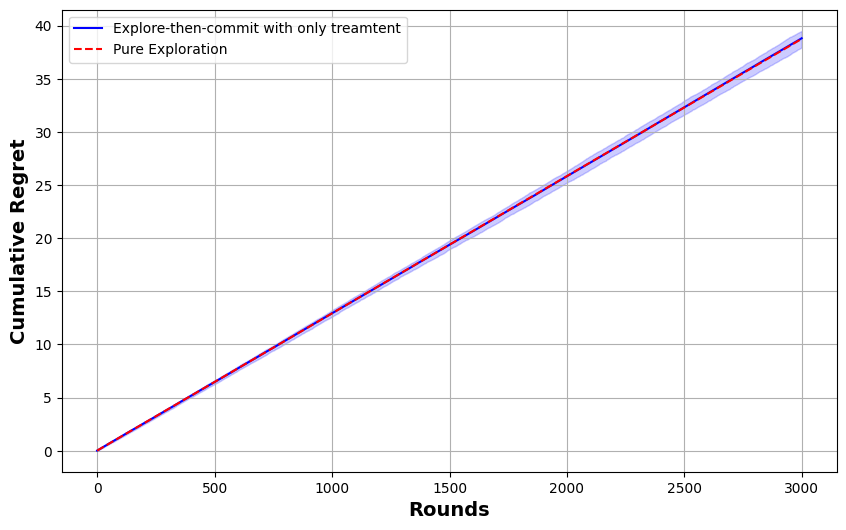

In [129]:
# 
all_cum_regrets = np.load("MC_simulation_results_regret_Z.npy", allow_pickle=True) #.item()
all_cum_regrets = all_cum_regrets[:, range(3000)]

# Compute mean and standard deviation across simulations
mean_cum_regret = np.mean(all_cum_regrets, axis=0)
quantile_15 = np.percentile(all_cum_regrets, 15, axis=0)  # 10th percentile
quantile_85 = np.percentile(all_cum_regrets, 85, axis=0)

# 
# Generate x-axis values (rounds)
x_values = np.arange(len(mean_cum_regret[:1000]))

# Fit a regression line to mean_cum_regret
slope, intercept, _, _, _ = linregress(x_values, mean_cum_regret[:1000])

# Compute the regression line values
regression_line = slope * np.arange(len(mean_cum_regret)) + intercept


# Display results
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(mean_cum_regret, label="Explore-then-commit with only treamtent", color="blue")
plt.fill_between(
    range(len(mean_cum_regret)),
    quantile_15,
    quantile_85,
    color="blue",
    alpha=0.2
)
plt.plot(regression_line, linestyle="--", color="red", label="Pure Exploration")

plt.xlabel("Rounds", fontsize=14, fontweight="bold")
plt.ylabel("Cumulative Regret", fontsize=14, fontweight="bold")
# plt.title("Monte Carlo Simulation: Cumulative Regret over 100 Runs", fontsize=16, fontweight="bold")
plt.legend()
plt.grid(True)
plt.savefig("regret.png")
plt.show()
